# Notebook 3: Model Comparison

**Learning Objectives:**
- Compare different ML algorithms
- Track multiple metrics for each model
- Visualize comparative results
- Select best model architecture

**Dataset:** Breast Cancer classification

In [ ]:
import mlflow
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

## Step 1: Load Data

In [2]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes: {cancer.target_names}")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Dataset: 569 samples, 30 features
Classes: ['malignant' 'benign']
Training set: (455, 30)
Test set: (114, 30)


## Step 2: Define Models to Compare

In [4]:
models = [
    {
        "name": "Random Forest",
        "model": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
        "params": {"n_estimators": 100, "max_depth": 10}
    },
    {
        "name": "Gradient Boosting",
        "model": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
        "params": {"n_estimators": 100, "learning_rate": 0.1}
    },
    {
        "name": "AdaBoost",
        "model": AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
        "params": {"n_estimators": 100, "learning_rate": 0.1}
    },
    {
        "name": "Logistic Regression",
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {"max_iter": 1000}
    },
    {
        "name": "SVM (RBF)",
        "model": SVC(kernel='rbf', probability=True, random_state=42),
        "params": {"kernel": "rbf"}
    },
    {
        "name": "K-Nearest Neighbors",
        "model": KNeighborsClassifier(n_neighbors=5),
        "params": {"n_neighbors": 5}
    },
    {
        "name": "Naive Bayes",
        "model": GaussianNB(),
        "params": {}
    }
]

print(f"Comparing {len(models)} different algorithms")

Comparing 7 different algorithms


## Step 3: Train and Compare All Models

In [5]:
mlflow.set_experiment("03_Model_Comparison")

results = []

for model_info in models:
    model_name = model_info["name"]
    model = model_info["model"]
    params = model_info["params"]
    
    with mlflow.start_run(run_name=model_name):
        
        # Log model type and parameters
        mlflow.log_param("model_type", model_name)
        mlflow.log_params(params)
        
        start_time = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        
        if y_pred_proba is not None:
            roc_auc = roc_auc_score(y_test, y_pred_proba)
        else:
            roc_auc = None
        
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        # Log all metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        if roc_auc:
            mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("cv_accuracy_mean", cv_mean)
        mlflow.log_metric("cv_accuracy_std", cv_std)
        mlflow.log_metric("training_time_sec", training_time)
        
        # Log model
        mlflow.sklearn.log_model(model, "model")
        
        results.append({
            "model": model_name,
            "accuracy": accuracy,
            "f1_score": f1,
            "precision": precision,
            "recall": recall,
            "roc_auc": roc_auc,
            "cv_mean": cv_mean,
            "cv_std": cv_std,
            "training_time": training_time
        })
        
        print(f"✓ {model_name}: accuracy={accuracy:.4f}, f1={f1:.4f}, time={training_time:.2f}s")

print("\n All models trained and logged!")

2026/02/09 00:27:49 INFO mlflow.tracking.fluent: Experiment with name '03_Model_Comparison' does not exist. Creating a new experiment.
2026/02/09 00:27:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/09 00:27:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✓ Random Forest: accuracy=0.9561, f1=0.9655, time=0.14s


2026/02/09 00:27:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/09 00:28:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✓ Gradient Boosting: accuracy=0.9561, f1=0.9660, time=0.52s


2026/02/09 00:28:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/09 00:28:09 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

✓ SVM (RBF): accuracy=0.9298, f1=0.9459, time=0.01s


2026/02/09 00:28:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/09 00:28:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✓ K-Nearest Neighbors: accuracy=0.9123, f1=0.9296, time=0.00s


2026/02/09 00:28:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/09 00:28:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✓ Naive Bayes: accuracy=0.9386, f1=0.9517, time=0.00s

 All models trained and logged!


## Step 4: Compare Results

In [6]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('accuracy', ascending=False)

print("\n" + "="*100)
print("MODEL COMPARISON RESULTS (Sorted by Accuracy)")
print("="*100)
print(df_results.to_string(index=False))

print("\n" + "="*100)
print("BEST MODEL")
print("="*100)
best = df_results.iloc[0]
print(f"Model:      {best['model']}")
print(f"Accuracy:   {best['accuracy']:.4f}")
print(f"F1 Score:   {best['f1_score']:.4f}")
print(f"Precision:  {best['precision']:.4f}")
print(f"Recall:     {best['recall']:.4f}")
if best['roc_auc']:
    print(f"ROC AUC:    {best['roc_auc']:.4f}")
print(f"CV Score:   {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")
print(f"Train Time: {best['training_time']:.2f}s")


MODEL COMPARISON RESULTS (Sorted by Accuracy)
              model  accuracy  f1_score  precision   recall  roc_auc  cv_mean   cv_std  training_time
Logistic Regression  0.964912  0.972603   0.959459 0.986111 0.996032 0.947253 0.017582       0.303079
  Gradient Boosting  0.956140  0.965986   0.946667 0.986111 0.990741 0.956044 0.013900       0.518627
      Random Forest  0.956140  0.965517   0.958904 0.972222 0.993717 0.953846 0.023466       0.141552
           AdaBoost  0.956140  0.965986   0.946667 0.986111 0.989418 0.962637 0.021534       0.258170
        Naive Bayes  0.938596  0.951724   0.945205 0.958333 0.987765 0.936264 0.004396       0.000970
          SVM (RBF)  0.929825  0.945946   0.921053 0.972222 0.969577 0.909890 0.028991       0.009709
K-Nearest Neighbors  0.912281  0.929577   0.942857 0.916667 0.955853 0.936264 0.018906       0.000000

BEST MODEL
Model:      Logistic Regression
Accuracy:   0.9649
F1 Score:   0.9726
Precision:  0.9595
Recall:     0.9861
ROC AUC:    0.996

## Step 5: Visualize Comparison

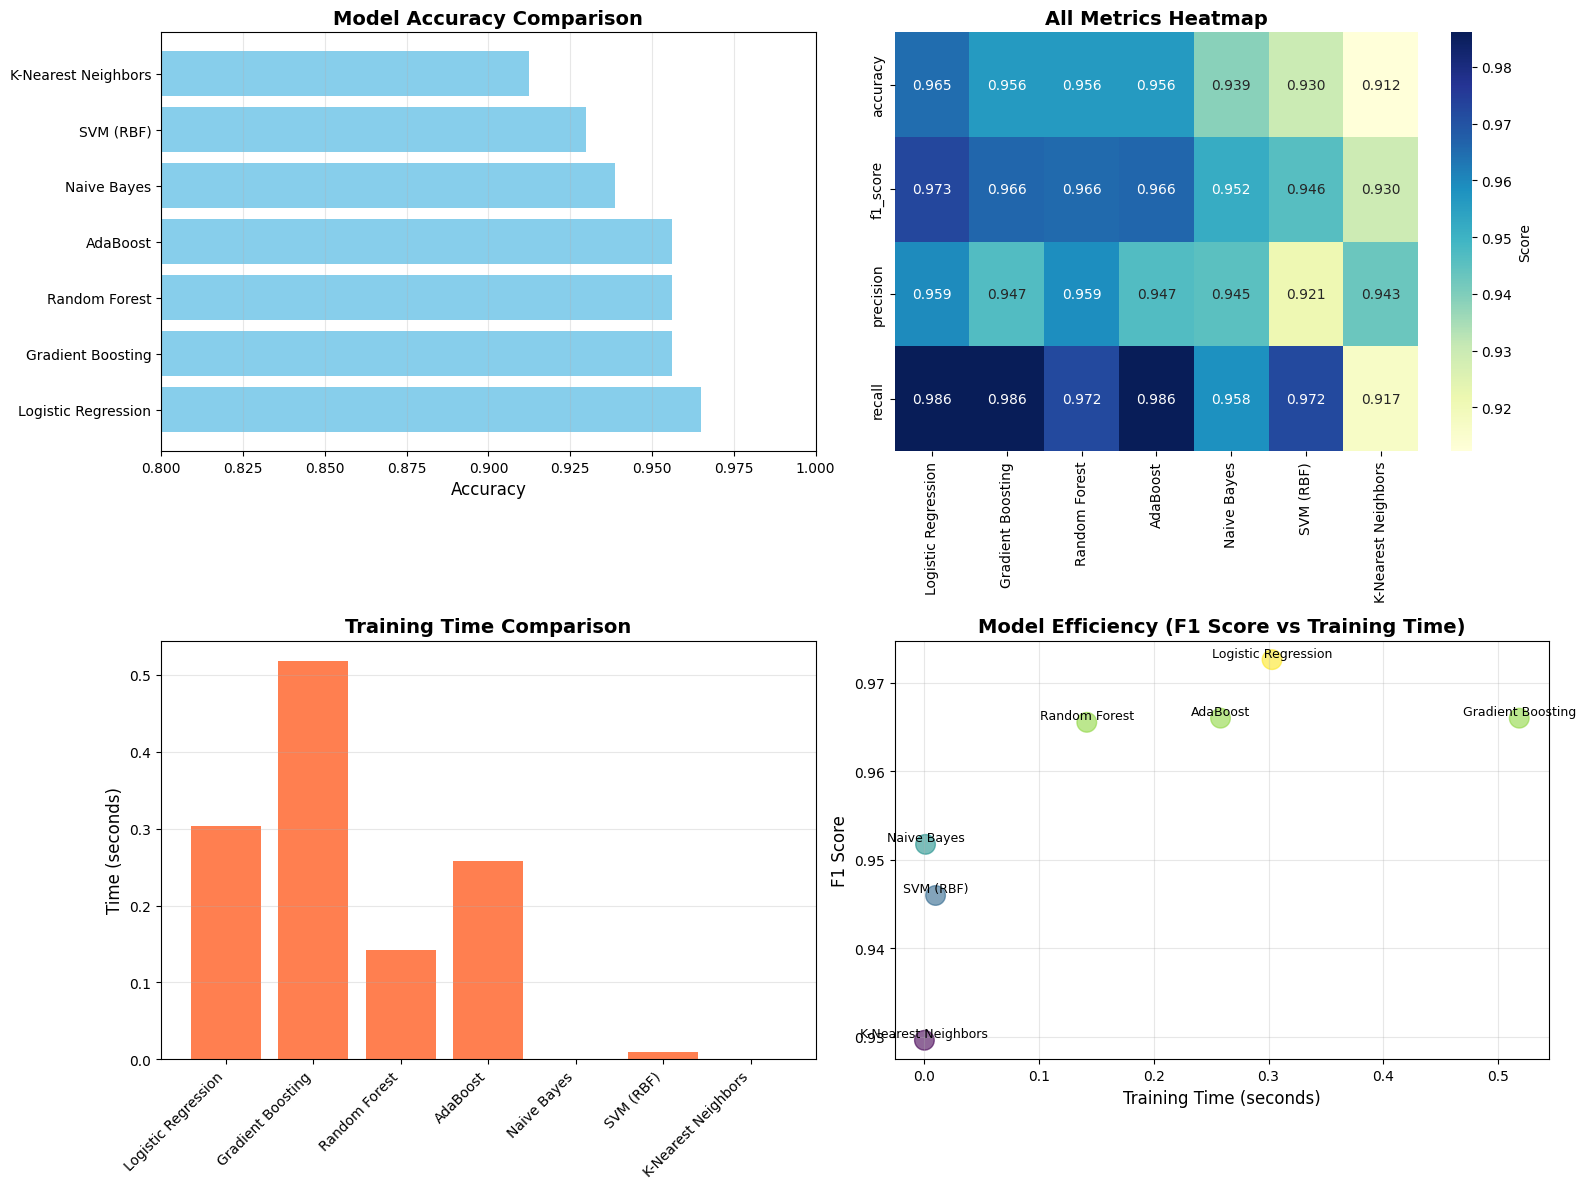


 Visualization saved: model_comparison.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Accuracy comparison
axes[0, 0].barh(df_results['model'], df_results['accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim([0.8, 1.0])
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: All metrics heatmap
metrics_df = df_results[['model', 'accuracy', 'f1_score', 'precision', 'recall']].set_index('model')
sns.heatmap(metrics_df.T, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0, 1], cbar_kws={'label': 'Score'})
axes[0, 1].set_title('All Metrics Heatmap', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('')

# Plot 3: Training time comparison
axes[1, 0].bar(range(len(df_results)), df_results['training_time'], color='coral')
axes[1, 0].set_xticks(range(len(df_results)))
axes[1, 0].set_xticklabels(df_results['model'], rotation=45, ha='right')
axes[1, 0].set_ylabel('Time (seconds)', fontsize=12)
axes[1, 0].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: F1 Score vs Training Time (efficiency)
axes[1, 1].scatter(df_results['training_time'], df_results['f1_score'], s=200, alpha=0.6, c=df_results['accuracy'], cmap='viridis')
for idx, row in df_results.iterrows():
    axes[1, 1].annotate(row['model'], (row['training_time'], row['f1_score']), 
                       fontsize=9, ha='center', va='bottom')
axes[1, 1].set_xlabel('Training Time (seconds)', fontsize=12)
axes[1, 1].set_ylabel('F1 Score', fontsize=12)
axes[1, 1].set_title('Model Efficiency (F1 Score vs Training Time)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Visualization saved: model_comparison.png")

## 🎯 Key Takeaways

1. **Multiple Models** - Easy to compare different algorithms
2. **Comprehensive Metrics** - Track multiple evaluation metrics
3. **Performance vs Efficiency** - Consider both accuracy and training time
4. **MLflow Organization** - All experiments organized in one place

## 📝 Exercise

1. Check MLflow UI to see all 7 model runs
2. Compare models using the "Compare" feature
3. Which model would you choose for production? Why?
4. Try adding DecisionTreeClassifier to the comparison